Mini-project: simple neural network on MNIST dataset

Understand MNIST dataset + prepare inputs for a neural network

In [1]:
import torch
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

In [2]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(device)

mps


Load MNIST and convert images to tensors:

In [3]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

Inspect the dataset:

In [4]:
print(len(train_dataset))  # should be 60000

image, label = train_dataset[0]

print(image.shape)  # (1, 28, 28)
print(label)        # 0–9

60000
torch.Size([1, 28, 28])
5


What that means:
- 60000 is the number of training samples (images)
- 1 is the number of channels (greyscale)
- 28 x 28 is the image size

This is our input X.

Visualize samples:

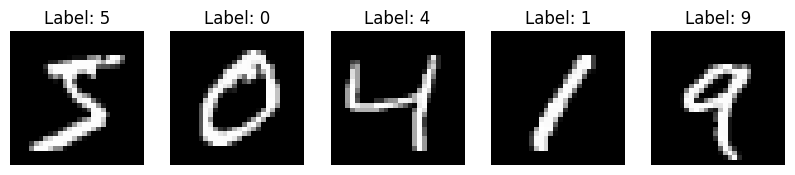

In [5]:
fig, ax = plt.subplots(1, 5, figsize=(10, 2))

for i in range(5):
    img, lbl = train_dataset[i]
    ax[i].imshow(img.squeeze(), cmap="gray")
    ax[i].set_title(f"Label: {lbl}")
    ax[i].axis("off")

plt.show()

Create DataLoader: this is how we feed batches to the model.

In [6]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

Inspect one batch:

In [7]:
images, labels = next(iter(train_loader))

print(images.shape)  # (32, 1, 28, 28)
print(labels.shape)  # (32,)

torch.Size([32, 1, 28, 28])
torch.Size([32])


How to interpret this:
- 32: batch size
- 1: number of channels
- 28 x 28: image size

So shape for a single batch is: (batch_size, channels, height, width) = (32, 1, 28, 28)

60000 / 32 means there are 1875 batches per epoch (1 epoch = one full pass over dataset = seeing all 60,000 images once)

Flatten images: neural networks expect vectors, not images

In [9]:
# images_flat = images.view(32, -1)
images_flat = images.view(images.size(0), -1) # more robust version (works for any batch size, not just 32)

print(images_flat.shape)  # (32, 784)

torch.Size([32, 784])


28 × 28 = 784 features so flatten shape is (batch_size, height x width) = (32, 28 x 28 = 784) 

-> This is our input vector X.

Summary:
- Dataset: 60,000 training images
- Input shape: (1, 28, 28)
- Batch shape: (32, 1, 28, 28)
- Flattened input: (32, 784)
- Each image = 784 features